In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-rush-unts-ultimate-regression-challenge/bodyfat-validate.csv
/kaggle/input/data-rush-unts-ultimate-regression-challenge/bodyfat-comp.csv


In [2]:
df = pd.read_csv("/kaggle/input/data-rush-unts-ultimate-regression-challenge/bodyfat-comp.csv")
df.head()

,Id,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,Person2,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
1,Person3,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
2,Person4,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
3,Person6,1.0502,20.9,24,210.25,74.75,39.0,104.5,94.4,107.8,66.0,42.0,25.6,35.7,30.6,18.8
4,Person7,1.0549,19.2,26,181.00,69.75,36.4,105.1,90.7,100.3,58.4,38.3,22.9,31.9,27.8,17.7


# **Basic data information**

In [3]:
df.shape

(168, 16)

In [4]:
df.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,1.055817,18.994048,44.720238,177.323214,70.053571,37.961310,100.194643,91.944048,99.618452,59.279167,38.470833,23.057143,32.196429,28.656548,18.173214
std,0.018204,8.098242,12.691610,25.441979,4.061756,2.192801,7.666736,9.747560,6.176463,4.688064,2.275102,1.508323,2.767409,1.948365,0.810668
min,0.995000,3.000000,22.000000,127.500000,29.500000,31.100000,83.400000,70.400000,85.300000,49.300000,33.400000,20.100000,25.600000,21.000000,16.300000
25%,1.041550,12.175000,35.000000,159.000000,68.250000,36.400000,93.825000,84.250000,95.575000,56.075000,36.900000,22.075000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,174.125000,70.000000,37.900000,99.550000,90.800000,99.150000,58.900000,38.300000,22.700000,31.950000,28.600000,18.250000
75%,1.071000,25.225000,54.000000,195.250000,72.250000,39.325000,104.750000,98.875000,103.125000,62.200000,39.725000,23.800000,34.300000,30.000000,18.800000
max,1.092600,47.500000,72.000000,244.250000,77.500000,43.900000,121.600000,122.100000,115.500000,72.900000,46.000000,33.900000,38.500000,34.900000,20.200000


In [5]:
df.isnull().sum() # No null values 

Id         0
Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

# **Exploratory data anlysis**

<AxesSubplot:xlabel='BodyFat', ylabel='Count'>

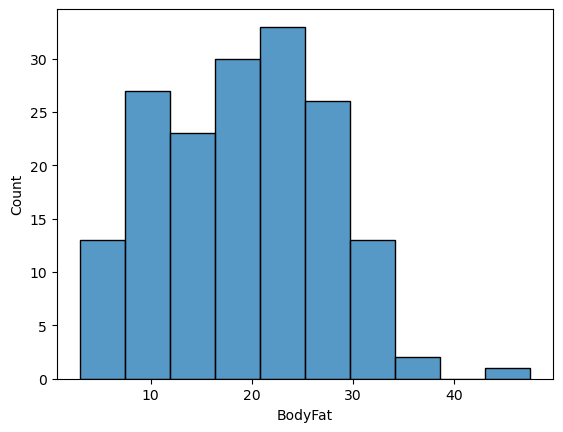

In [6]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.histplot(x =  'BodyFat', data = df)

* We see that people with body fat percentage of above 40 are outliers. We can exclude them from the prediction.

<AxesSubplot:xlabel='BodyFat', ylabel='Count'>

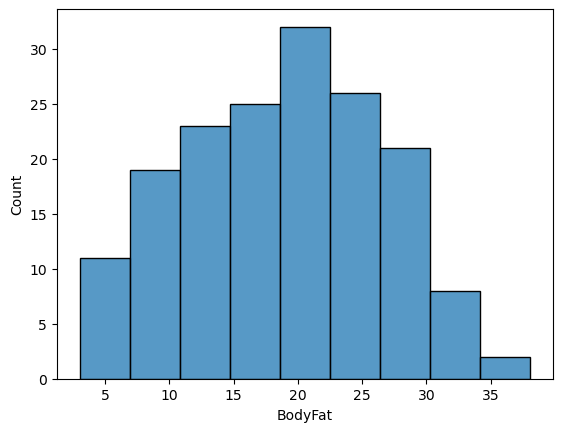

In [7]:
df = df[df['BodyFat'] <= 40]

sns.histplot(x =  'BodyFat', data = df)

* The dataset is now more normally distributed. 

<AxesSubplot:xlabel='Age', ylabel='Count'>

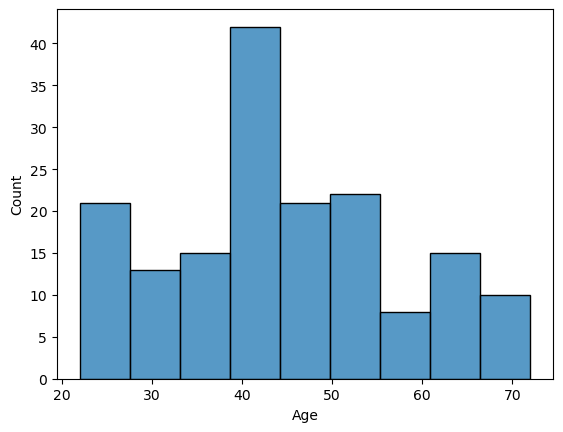

In [8]:
sns.histplot(x =  'Age', data = df)

* Most participants in this study are in the mid forties.

<AxesSubplot:xlabel='Height', ylabel='Count'>

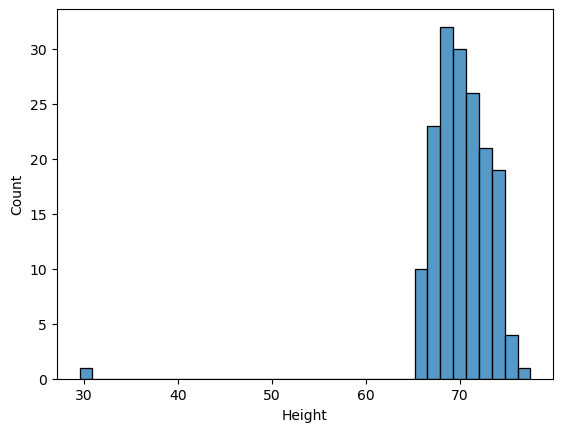

In [9]:
sns.histplot(x =  'Height', data = df)

* There is an outlier whose height is near 30. We check the details of this person.

In [10]:
df[df['Height'] <= 40]

,Id,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
23,Person42,1.025,32.9,44,205.0,29.5,36.6,106.0,104.3,115.5,70.6,42.5,23.7,33.6,28.7,17.4


* Given that this person is already 44 years old and not a child, this might be a typo or outlier case. Hence, we also remove this instance. 

<AxesSubplot:xlabel='Height', ylabel='Count'>

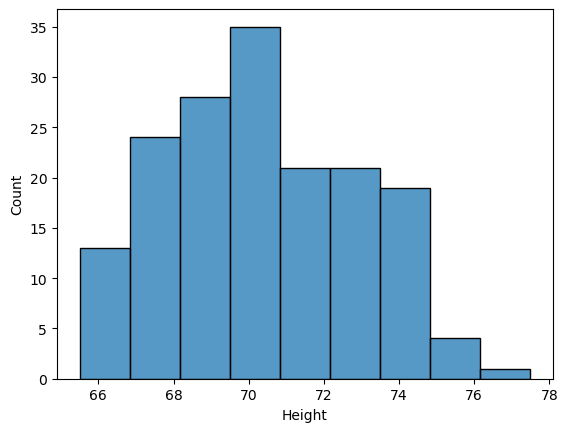

In [11]:
df = df[df['Height'] >= 40]

sns.histplot(x =  'Height', data = df)

<AxesSubplot:xlabel='Weight', ylabel='Count'>

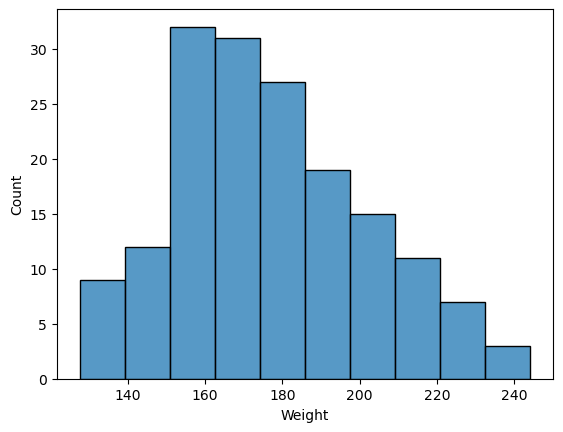

In [12]:
sns.histplot(x = 'Weight', data = df)

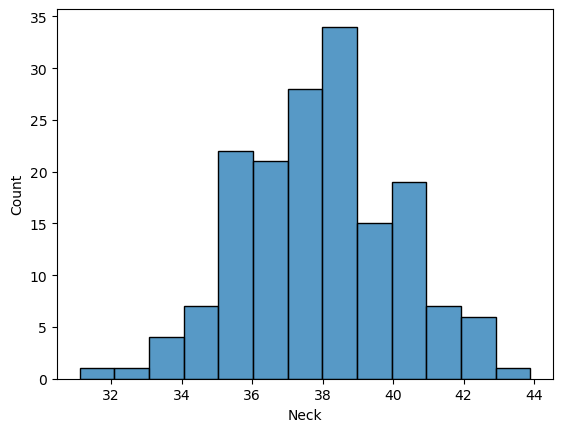

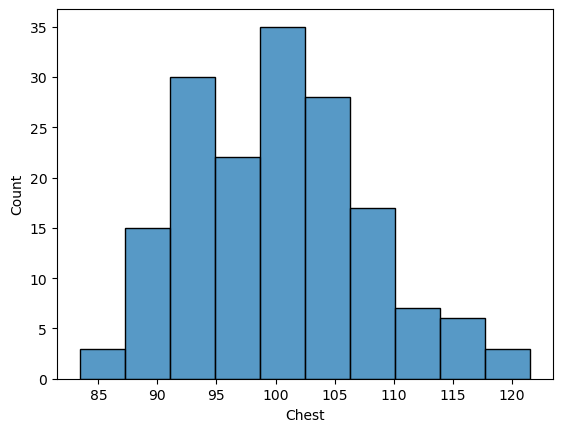

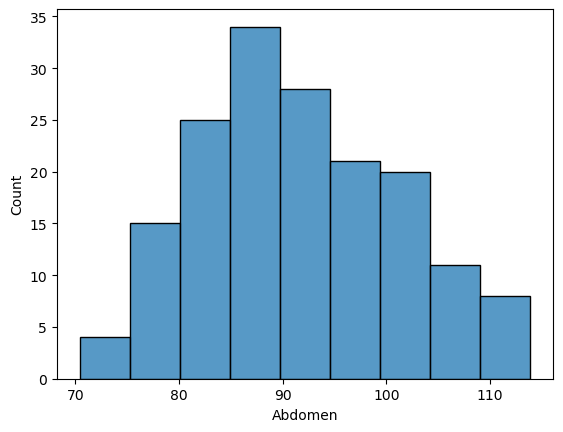

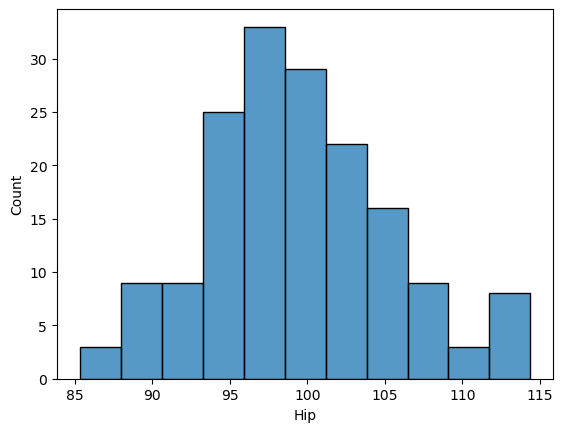

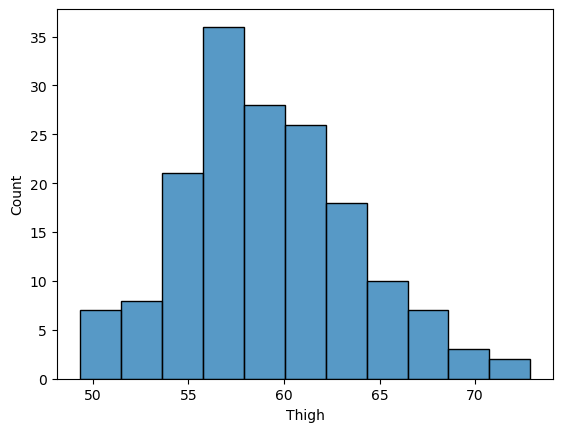

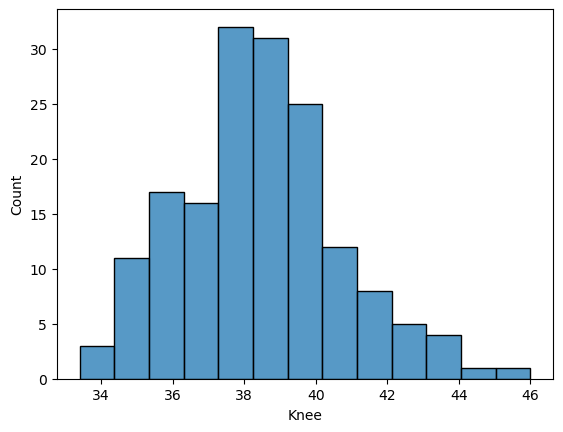

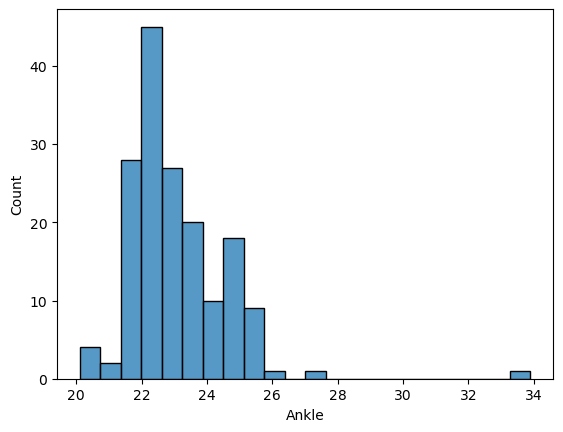

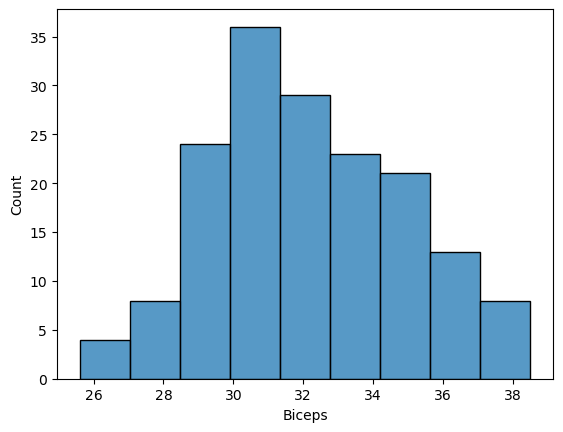

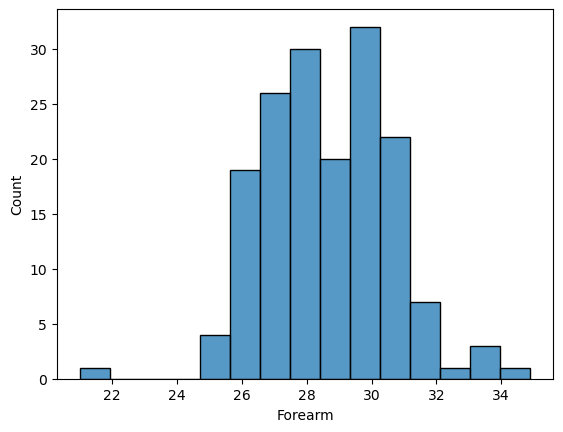

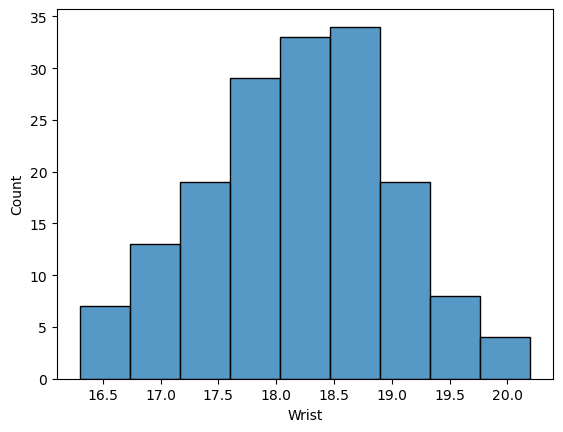

In [13]:
for i in ['Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']: 
    sns.histplot(x =  i, data = df)
    plt.show()

* There is an outlier associated with ankle. We remove the outlier.

<AxesSubplot:xlabel='Ankle', ylabel='Count'>

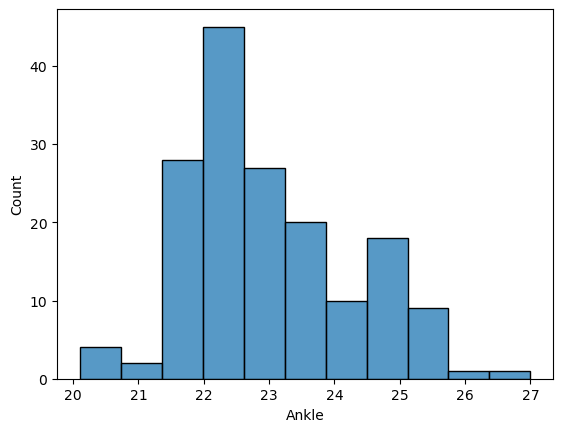

In [14]:
df = df[df['Ankle'] <= 30]
sns.histplot(x = 'Ankle', data = df)

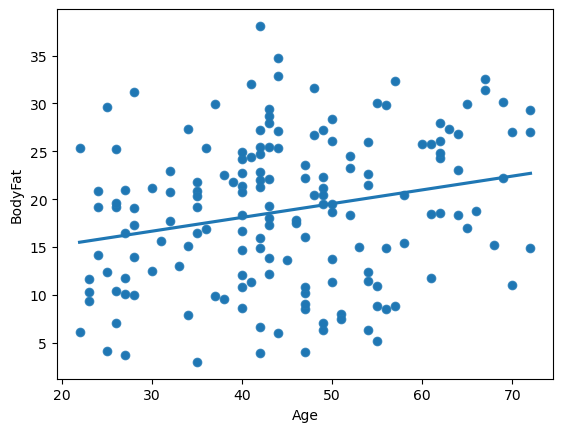

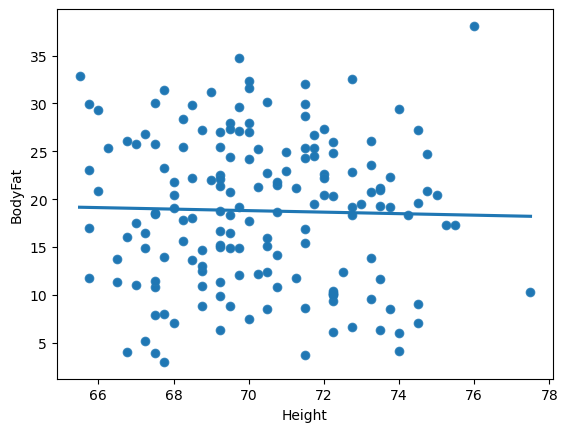

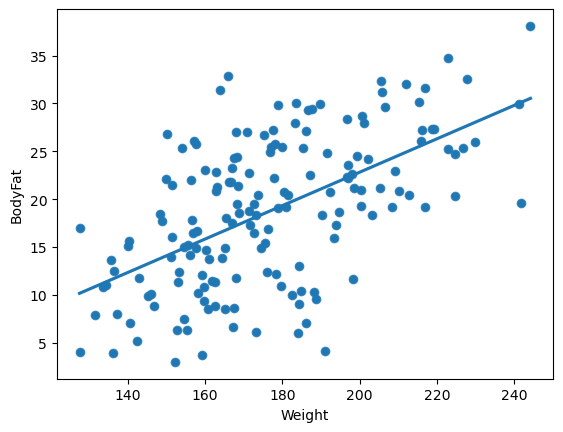

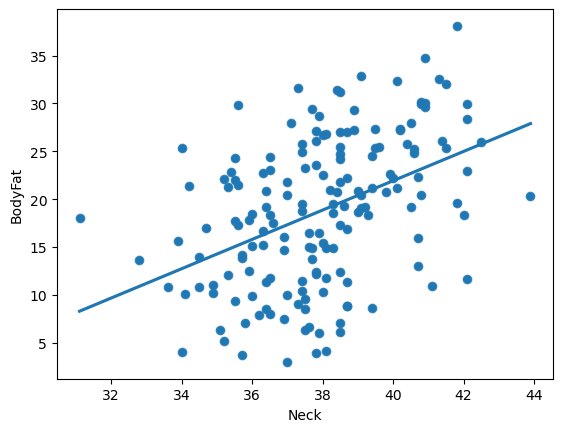

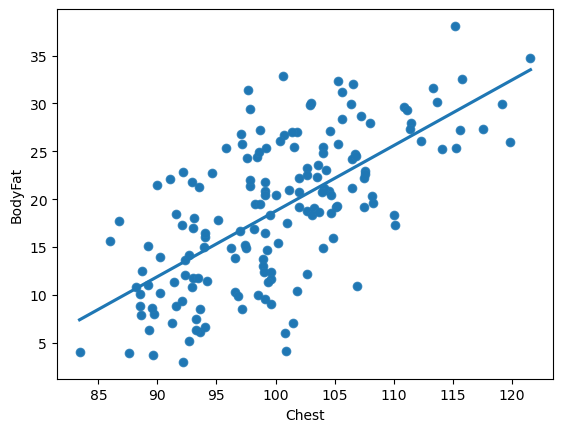

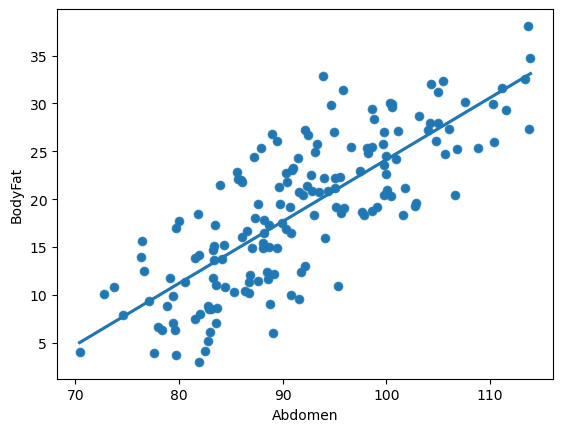

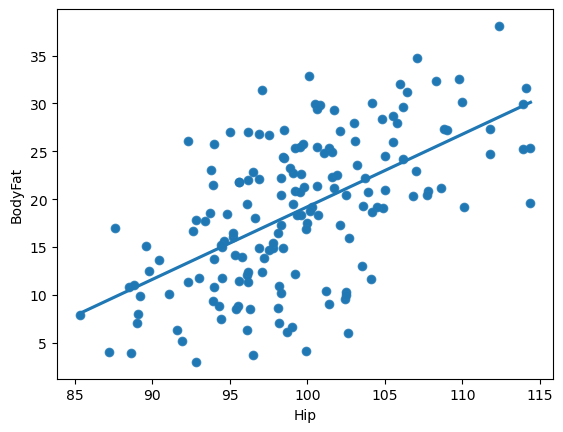

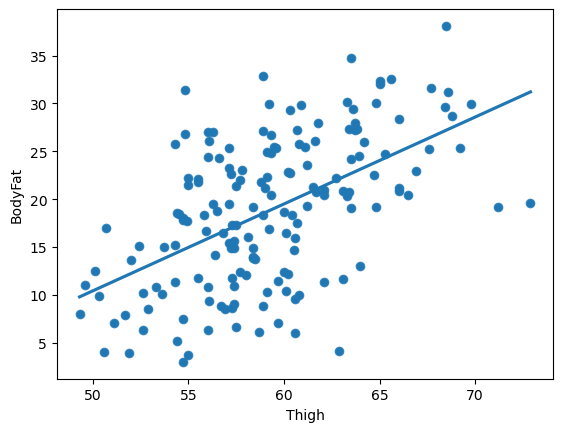

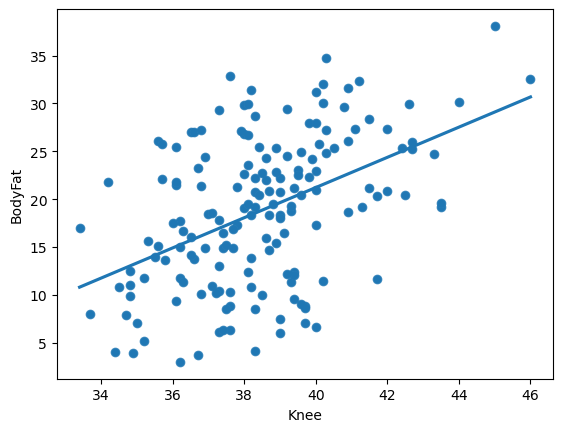

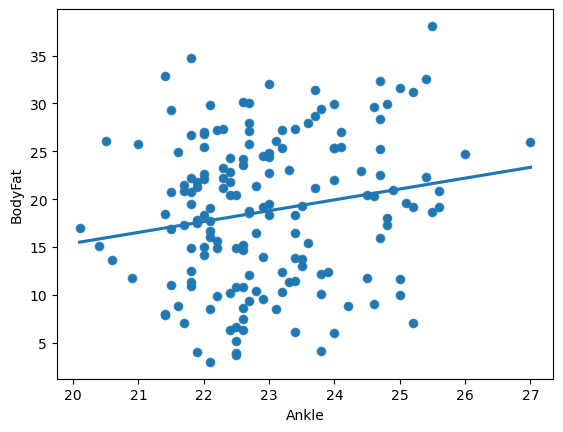

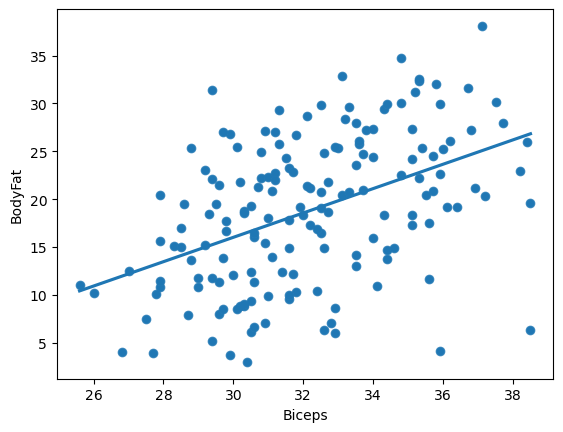

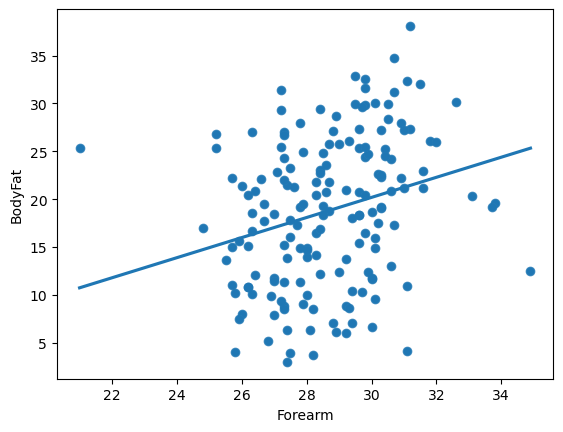

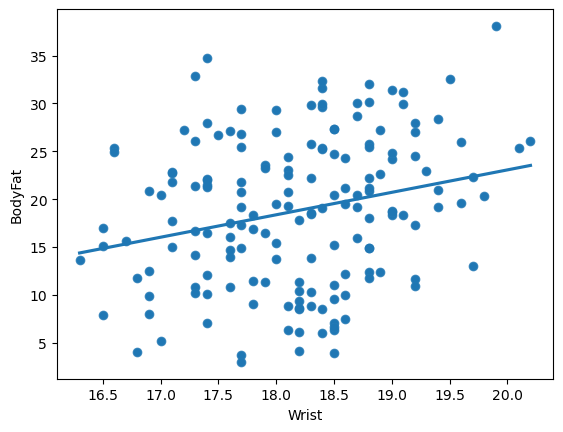

In [15]:
for i in ['Age', 'Height', 'Weight', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']:
    sns.scatterplot(x = i, y = 'BodyFat', data = df)
    sns.regplot(x=i, y='BodyFat', data=df, ci = None)
    plt.show()

<AxesSubplot:>

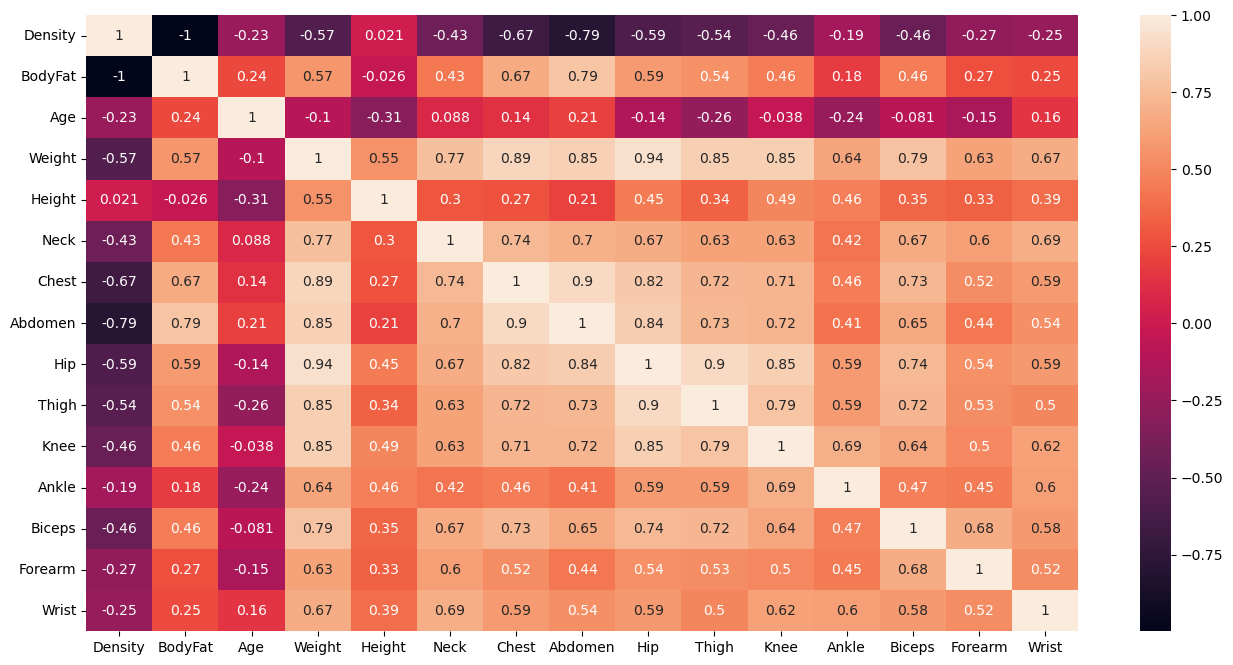

In [16]:
plt.figure(figsize = (16,8))
sns.heatmap(df.corr(), annot = True)

# **Baseline prediction (Linear Regression)**

In [17]:
X = df.drop(['Id', 'Density', 'BodyFat'], axis = 1)
y = df['BodyFat']

from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(X_test.shape)

(132, 13)
(33, 13)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
error = np.sqrt(mean_squared_error(y_pred, y_test))
error 

4.14615502143299

# **Linear Regression (With scaling)**

In [19]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred = lr.predict(X_test_sc)
error = np.sqrt(mean_squared_error(y_pred, y_test))
error 

4.146155021432991

* Scaling does not give much difference in the accuracy. We proceed without scaling. 

# **Linear Regression (Removing some variables)**
* We predict using variables with correlation > 0.4. 

In [20]:
X_corr = X.drop(['Age', 'Height', 'Ankle', 'Wrist'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X_corr, y, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(X_test.shape)

(132, 9)
(33, 9)


In [21]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
error = np.sqrt(mean_squared_error(y_pred, y_test))
error 

4.173340082414929

# **Test prediction**

In [22]:
df_test = pd.read_csv('/kaggle/input/data-rush-unts-ultimate-regression-challenge/bodyfat-validate.csv')
df_test.head()

,Id,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,Person68,55,154.75,71.50,36.9,95.4,86.6,91.8,54.3,35.4,21.5,32.8,27.4,18.7
1,Person252,74,207.50,70.00,40.8,112.4,108.5,107.1,59.3,42.2,24.6,33.7,30.0,20.9
2,Person232,57,182.25,71.75,39.4,103.4,96.7,100.7,59.3,38.6,22.8,31.8,29.1,19.0
3,Person162,33,196.00,73.00,38.5,103.8,95.6,105.1,61.4,40.6,25.0,31.3,29.2,19.1
4,Person92,44,179.75,69.50,39.2,101.9,93.2,100.6,58.9,39.7,23.1,31.4,28.4,18.8


In [23]:
X_test_new = df_test.drop(['Id', 'Age', 'Height', 'Ankle', 'Wrist'], axis = 1)

In [24]:
y_pred = lr.predict(X_test_new)
pd.DataFrame(y_pred).head()

,0
0,17.476335
1,27.606467
2,21.851720
3,18.921831
4,18.284241


In [25]:
df_test['prediction'] = y_pred
df_test.head()

,Id,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,prediction
0,Person68,55,154.75,71.50,36.9,95.4,86.6,91.8,54.3,35.4,21.5,32.8,27.4,18.7,17.476335
1,Person252,74,207.50,70.00,40.8,112.4,108.5,107.1,59.3,42.2,24.6,33.7,30.0,20.9,27.606467
2,Person232,57,182.25,71.75,39.4,103.4,96.7,100.7,59.3,38.6,22.8,31.8,29.1,19.0,21.851720
3,Person162,33,196.00,73.00,38.5,103.8,95.6,105.1,61.4,40.6,25.0,31.3,29.2,19.1,18.921831
4,Person92,44,179.75,69.50,39.2,101.9,93.2,100.6,58.9,39.7,23.1,31.4,28.4,18.8,18.284241


In [26]:
my_submission = pd.DataFrame({'Id': df_test.Id, 'BodyFat': y_pred})
my_submission.to_csv('submission.csv', index=False)